In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

# Problem 3: Greedy Initialization of k-means

In this problem, you will compare two different initializations of the k-means algorithm.

Let's consider the following dataset

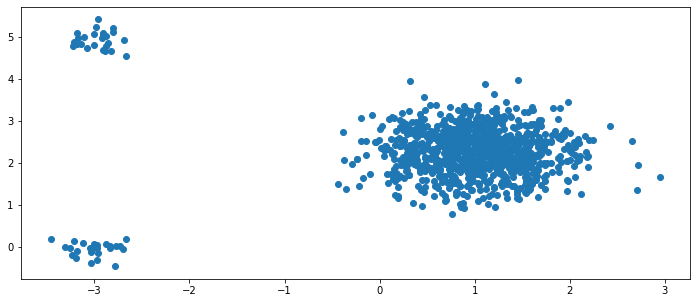

In [12]:
X = np.zeros((1000,2))

X[0:25] = 0.2*np.random.randn(25,2) + [-3,0] # blob 1
X[25:50] = 0.2*np.random.randn(25,2) + [-3,5] # blob 2
X[50:1000] = 0.5*np.random.randn(950,2) + [1,2.25] # blob 3

plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1])

This dataset has three clusters (one big blog, and two smaller blobs).

**Random initialization:** the initial cluster's centers are randomly chosen from the dataset points.

In [3]:
k = 3 # nuber of clusters
m = 1000 # number of datapoints
means = X[np.random.choice(m,k)] # initial k means

In [4]:
# initial clusters
dist = pairwise_distances(X,means)
clusters = np.argmin(dist, axis=1)

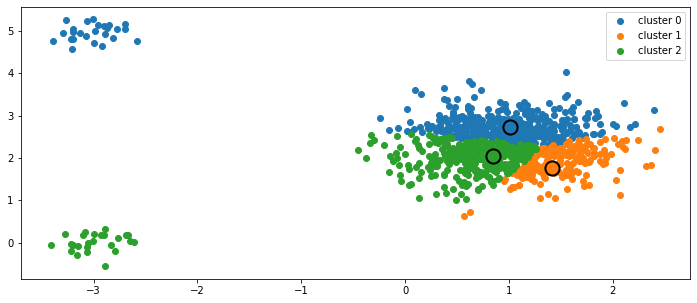

In [5]:
plt.figure(figsize=(12,5))
colors = ['C0','C1','C2']
for i in range(k):
    # plot dataset points
    plt.scatter(X[clusters==i,0],X[clusters==i,1],color=colors[i], label = 'cluster '+str(i))
    # plot cluster mean'
    plt.scatter(means[i,0],means[i,1],
                marker='o',
                s= 200,  
                linewidths = 2,
                color = colors[i], 
                edgecolors='black')
plt.legend()

**Greedy initialization:** consider the following initialization method which we denote as the *greedy initialization method*:

- For the first cluster center, pick one of the dataset points at random.
- Pick each remaining cluster center as the dataset point as far from the previous centers as possible.

## Part 1

Compute the initial clusters (with k=3) if the initial cluster's centers are chosen using the greedy initialization.

In [13]:
# pick first cluster center

center1 = X[np.random.choice(m)]

center1

array([0.59015255, 2.77204888])

In [16]:
# find distances from all points to center1

dist = pairwise_distances(X,center1.reshape(1,-1))

In [18]:
center2 = X[np.argmax(dist)]

center2

array([-3.19560569, -0.25905617])

In [19]:
centers = np.zeros((2,2))
centers[0] = center1
centers[1] = center2

dist = pairwise_distances(X,centers)

below, sum_dist is a vector with sum_dist[i] storing the sum of distances from point X[i] to centers.

In [24]:
sum_dist = np.sum(dist, axis=1)

center3 = X[np.argmax(sum_dist)]

center3

array([-2.96206968,  5.41466034])

## Part 2

Plot the initial clusters

In [26]:
means = np.zeros((3,2))
means[0]= center1
means[1] = center2
means[2] = center3

In [27]:
# initial clusters
dist = pairwise_distances(X,means)
clusters = np.argmin(dist, axis=1)

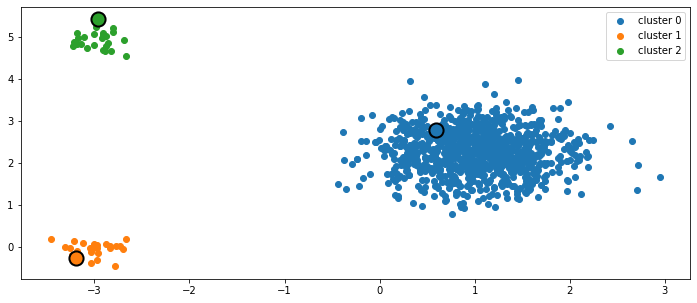

In [28]:
plt.figure(figsize=(12,5))
colors = ['C0','C1','C2']
for i in range(k):
    # plot dataset points
    plt.scatter(X[clusters==i,0],X[clusters==i,1],color=colors[i], label = 'cluster '+str(i))
    # plot cluster mean'
    plt.scatter(means[i,0],means[i,1],
                marker='o',
                s= 200,  
                linewidths = 2,
                color = colors[i], 
                edgecolors='black')
plt.legend()